In [1]:
# !pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow joblib tf2onnx xgboost

In [2]:
import os, json, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, f1_score,
                             accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from google.colab import files   # uncomment on Colab

In [3]:
uploaded = files.upload()

FILE_NAME = "audit_trail_2025.csv"
df = pd.read_csv(FILE_NAME)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Saving audit_trail_2025.csv to audit_trail_2025.csv
Loaded 88,060 rows × 30 columns


,id,insuredId,status,sessionId,action,httpCode,ip,userAgent,requestData,requestReturn,...,domainIdList,subType,countryCode,city,month,sessionNumber,sequenceInSession,sessionLength,is_anomaly,anomaly_type
0,8fe15e99-9a74-48e0-a9b0-b2026aa5cde7,90485386,OK,6632281,Connexion,200,87.123.159.43,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) A...,"{""login"": ""90485386"", ""channel"": ""web"", ""count...",NaN,...,[10],logging_login,DE,Hamburg,2025-01,7,1,6,1,unusual_hour
1,80a30274-c621-47d0-bf7e-c9746027579a,90485386,OK,6632281,Validation MFA,204,87.123.159.43,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) A...,"{""login"": ""90485386"", ""channel"": ""web"", ""count...",NaN,...,[10],logging_mfa_validation,DE,Hamburg,2025-01,7,2,6,1,unusual_hour
2,2d9efae8-daf9-40bb-9a2d-c4d997672b52,90485386,KO,6632281,Changer l'organisme de rattachement sécu. Social,400,87.123.159.43,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) A...,"{""insuredId"": ""90485386"", ""action"": ""Changer l...","{""status"": ""error"", ""code"": ""VALIDATION_ERROR""}",...,[10],change_social_security_provider,DE,Hamburg,2025-01,7,3,6,1,unusual_hour
3,d1c8708f-3b30-41e2-846f-f5785a20635f,90485386,KO,6632281,Ajout de la carte tiers payant dans le wallet,422,87.123.159.43,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) A...,"{""insuredId"": ""90485386"", ""action"": ""Ajout de ...","{""status"": ""error"", ""code"": ""SERVER_ERROR""}",...,[10],add_third_party_card_to_wallet_ios,DE,Hamburg,2025-01,7,4,6,1,unusual_hour
4,c9cc371a-09cd-4987-b301-e867580d9c8b,90485386,OK,6632281,Changer ses informations personnel,204,87.123.159.43,Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) A...,"{""insuredId"": ""90485386"", ""action"": ""Changer s...",NaN,...,[],update_personal_information,DE,Hamburg,2025-01,7,5,6,1,unusual_hour


In [4]:
df["createdAt"] = pd.to_datetime(df["createdAt"], utc=True, errors="coerce")

list_cols = ["companyIdList","companyGroupIdList","insurerIdList",
             "companySectionIdList","insurerCodeIdList",
             "healthcareNetworkIdList","domainIdList"]
for c in list_cols:
    df[c] = df[c].fillna("[]").astype(str)

text_cols = ["action","type","subType","device","countryCode","city","status","userAgent","anomaly_type"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna("UNKNOWN").astype(str)

if "is_anomaly" not in df.columns:
    df["is_anomaly"] = 0
if "anomaly_type" not in df.columns:
    df["anomaly_type"] = "normal"
if "sessionLength" not in df.columns:
    df["sessionLength"] = df.groupby(["insuredId","sessionNumber"])["sequenceInSession"].transform("max")

df = df.sort_values(["insuredId","sessionNumber","sequenceInSession"]).reset_index(drop=True)
print("Normal rows  :", (df["is_anomaly"] == 0).sum())
print("Anomaly rows :", (df["is_anomaly"] == 1).sum())
if df["is_anomaly"].sum() > 0:
    print("Anomaly types:\n", df[df["is_anomaly"]==1]["anomaly_type"].value_counts())

Normal rows  : 83610
Anomaly rows : 4450
Anomaly types:
 anomaly_type
impossible_seq    996
repeated_fail     990
rapid_fire        680
unusual_hour      597
skip_login        596
geo_jump          591
Name: count, dtype: int64


In [5]:
df["hour"]      = df["createdAt"].dt.hour
df["dayofweek"] = df["createdAt"].dt.dayofweek
df["month_num"] = df["createdAt"].dt.month
df["hour_sin"]  = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]  = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]   = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]   = np.cos(2*np.pi*df["dayofweek"]/7)
df["is_ok"] = (df["status"]=="OK").astype(int)
df["is_ko"] = (df["status"]=="KO").astype(int)

In [6]:
action_le  = LabelEncoder()
device_le  = LabelEncoder()
country_le = LabelEncoder()
type_le    = LabelEncoder()
subtype_le = LabelEncoder()

df["action_id"]       = action_le.fit_transform(df["action"])
df["device_id"]       = device_le.fit_transform(df["device"])
df["country_id"]      = country_le.fit_transform(df["countryCode"])
df["type_id"]         = type_le.fit_transform(df["type"])
df["subType_filled"]  = df["subType"].fillna("NONE").astype(str)
df["subtype_id"]      = subtype_le.fit_transform(df["subType_filled"])

print("Unique actions:", len(action_le.classes_))

Unique actions: 43


In [7]:
SESSION_KEY = ["insuredId","sessionNumber"]
df["prev_time"]  = df.groupby(SESSION_KEY)["createdAt"].shift(1)
df["delta_seconds"] = (df["createdAt"]-df["prev_time"]).dt.total_seconds().fillna(0)
df["delta_seconds_clipped"] = df["delta_seconds"].clip(0, 3600)

scaler_delta = StandardScaler()
df["delta_scaled"] = scaler_delta.fit_transform(df[["delta_seconds_clipped"]])

In [8]:
df["seq_pos_norm"]     = df["sequenceInSession"] / df["sessionLength"]
df["is_session_start"] = (df["sequenceInSession"]==1).astype(int)
df["is_session_end"]   = (df["sequenceInSession"]==df["sessionLength"]).astype(int)
df["prev_action_id"]   = (df.groupby(SESSION_KEY)["action_id"].shift(1).fillna(-1).astype(int)+1)
df["ko_count_so_far"]  = (df.groupby(SESSION_KEY)["is_ko"].cumsum().shift(1).fillna(0).astype(int))
max_session_len        = df["sessionLength"].max()
df["session_len_norm"] = df["sessionLength"] / max_session_len

# ★ NEW: ip_changed_flag (within session) — key geo_jump signal
df["ip_prev"] = df.groupby(SESSION_KEY)["ip"].shift(1)
df["ip_changed"] = ((df["ip"]!=df["ip_prev"]) & df["ip_prev"].notna()).astype(int)

# For geo_jump: was the IP EVER different within this session?
# Propagate forward so the full window carries the signal
df["had_ip_change"] = df.groupby(SESSION_KEY)["ip_changed"].cummax()

# For rapid_fire: minimum time gap seen so far in session
df["min_delta_so_far"] = (
    df.groupby(SESSION_KEY)["delta_seconds_clipped"]
    .cummin()
    .shift(1).fillna(df["delta_seconds_clipped"])
)

print("Session features ready.")

Session features ready.


In [9]:
SEQ_LEN = 10

feature_cols = [
    # Categorical
    "action_id","device_id","country_id","type_id","subtype_id",
    "prev_action_id",
    # Temporal
    "hour_sin","hour_cos","dow_sin","dow_cos","month_num",
    # Time gap
    "delta_scaled",
    # Status
    "is_ok","is_ko",
    # Session context
    "seq_pos_norm","is_session_start","is_session_end","session_len_norm",
    "ko_count_so_far",
    # ★ NEW
    "ip_changed",
    "had_ip_change",      # ★ geo_jump signal (persistent across window)
    "min_delta_so_far",   # ★ rapid_fire signal (cumulative minimum gap)
]
print(f"Feature vector size: {len(feature_cols)}")

Feature vector size: 22


In [10]:
def build_sequences(df, seq_len=10, include_anomaly_label=False):
    X, y_next, y_anomaly, y_atype, meta = [], [], [], [], []
    atype_le_local = None
    if include_anomaly_label:
        atype_le_local = LabelEncoder()
        df["anomaly_type_id"] = atype_le_local.fit_transform(df["anomaly_type"].fillna("normal"))

    for (uid, snum), g in df.groupby(SESSION_KEY):
        g = g.sort_values("sequenceInSession")
        vals    = g[feature_cols].values.astype(np.float32)
        actions = g["action_id"].values
        times   = g["createdAt"].values
        sess_anom = int(g["is_anomaly"].max()) if "is_anomaly" in g else 0
        sess_type = g["anomaly_type"].iloc[0] if "anomaly_type" in g.columns else "normal"

        n = len(g)
        if n < 2:
            continue
        for end in range(1, n):
            start = max(0, end - seq_len)
            seq   = vals[start:end]
            # Changed to POST-PADDING (padding at the end) for cuDNN compatibility
            if len(seq) < seq_len:
                pad = np.zeros((seq_len-len(seq), len(feature_cols)), dtype=np.float32)
                seq = np.vstack([seq, pad])
            X.append(seq)
            y_next.append(actions[end])
            y_anomaly.append(sess_anom)
            y_atype.append(sess_type)
            meta.append({"insuredId": uid, "sessionNumber": snum,
                         "end_time": str(times[end-1]), "next_time": str(times[end])})

    return (np.array(X, dtype=np.float32),
            np.array(y_next, dtype=np.int32),
            np.array(y_anomaly, dtype=np.int32),
            y_atype, meta, atype_le_local)

X_all, y_all, y_anom_all, y_atype_all, meta_all, _ = build_sequences(df, SEQ_LEN, include_anomaly_label=False)
print("X_all:", X_all.shape, "| y_all:", y_all.shape)

X_all: (69915, 10, 22) | y_all: (69915,)


In [11]:
meta_df  = pd.DataFrame(meta_all)
meta_df["end_time"] = pd.to_datetime(meta_df["end_time"], utc=True)
order    = np.argsort(meta_df["end_time"].values)
X_all    = X_all[order];   y_all = y_all[order]
y_anom_all  = y_anom_all[order]
y_atype_all = [y_atype_all[i] for i in order]
meta_df  = meta_df.iloc[order].reset_index(drop=True)

split    = int(len(X_all)*0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
y_anom_train, y_anom_test = y_anom_all[:split], y_anom_all[split:]
y_atype_train = y_atype_all[:split];  y_atype_test = y_atype_all[split:]

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Anomaly in train: {y_anom_train.sum()}  Anomaly in test: {y_anom_test.sum()}")

Train: (55932, 10, 22)  Test: (13983, 10, 22)
Anomaly in train: 2830  Anomaly in test: 702


In [12]:
artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

for name, le in [("action",action_le),("device",device_le),
                 ("country",country_le),("type",type_le),("subtype",subtype_le)]:
    with open(f"{artifacts_dir}/{name}_vocab.json","w",encoding="utf-8") as f:
        json.dump({int(i): cls for i,cls in enumerate(le.classes_)}, f, ensure_ascii=False, indent=2)

joblib.dump(scaler_delta, f"{artifacts_dir}/scaler_delta.pkl")
json.dump({
    "seq_len": SEQ_LEN, "feature_cols": feature_cols,
    "n_features": len(feature_cols),
    "action_vocab_size": int(len(action_le.classes_)),
    "device_vocab_size": int(len(device_le.classes_)),
    "country_vocab_size": int(len(country_le.classes_)),
    "type_vocab_size": int(len(type_le.classes_)),
    "subtype_vocab_size": int(len(subtype_le.classes_)),
    "max_session_len": int(max_session_len),
}, open(f"{artifacts_dir}/feature_config.json","w"), ensure_ascii=False, indent=2)

print("Artefacts saved.")

#  ██████╗  █████╗ ██████╗ ████████╗     █████╗
#  ██╔══██╗██╔══██╗██╔══██╗╚══██╔══╝    ██╔══██╗
#  ██████╔╝███████║██████╔╝   ██║       ███████║
#  ██╔═══╝ ██╔══██║██╔══██╗   ██║       ██╔══██║
#  ██║     ██║  ██║██║  ██║   ██║       ██║  ██║
#  ╚═╝     ╚═╝  ╚═╝╚═╝  ╚═╝   ╚═╝       ╚═╝  ╚═╝
#  LSTM AUTOENCODER — Anomaly DETECTION (binary)

Artefacts saved.


In [13]:
# Train ONLY on sequences with no anomaly → model learns "normal"
normal_train_mask = (y_anom_train == 0)
X_train_ae = X_train[normal_train_mask]

# For evaluation: split test into normal vs anomaly subsets
normal_test_mask  = (y_anom_test == 0)
anomaly_test_mask = (y_anom_test == 1)
X_test_normal  = X_test[normal_test_mask]
X_test_anomaly = X_test[anomaly_test_mask]

print(f"AE train (normal only): {X_train_ae.shape}")
print(f"AE test  normal  : {X_test_normal.shape}")
print(f"AE test  anomaly : {X_test_anomaly.shape}")

AE train (normal only): (53102, 10, 22)
AE test  normal  : (13281, 10, 22)
AE test  anomaly : (702, 10, 22)


In [14]:
input_dim = X_train.shape[-1]

ae_inputs = layers.Input(shape=(SEQ_LEN, input_dim))
# Masking 0.0 works with post-padding for cuDNN
x = layers.Masking(mask_value=0.0)(ae_inputs)

# Encoder
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Dropout(0.20)(x)
x = layers.LSTM(32, return_sequences=False)(x)

# Bottleneck
x = layers.RepeatVector(SEQ_LEN)(x)

# Decoder
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.20)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
ae_outputs = layers.TimeDistributed(layers.Dense(input_dim))(x)

autoencoder = models.Model(ae_inputs, ae_outputs, name="lstm_autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
autoencoder.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10, 22)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 10, 22)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 10)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 128)   │     44,544 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     20,608 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 32)    │          0 │ lstm_1[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 32)    │      8,320 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 32)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 10, 128)   │     49,664 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 22)    │      2,838 │ bidirectional_1[… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,974 (492.09 KB)

 Trainable params: 125,974 (492.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 4.8147 - val_loss: 2.5433 - learning_rate: 0.0010
Epoch 2/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.7879 - val_loss: 1.5973 - learning_rate: 0.0010
Epoch 3/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 1.1708 - val_loss: 1.1563 - learning_rate: 0.0010
Epoch 4/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.8880 - val_loss: 0.9651 - learning_rate: 0.0010
Epoch 5/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.7284 - val_loss: 0.8543 - learning_rate: 0.0010
Epoch 6/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.6189 - val_loss: 0.7670 - learning_rate: 0.0010
Epoch 7/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.5496 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 8/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.5022 - val_loss: 0.6615 - learning_rate: 0.0010
Epoch 9/60
353/353 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.4546 - val_loss: 0.6232 - learning_rate: 0.001

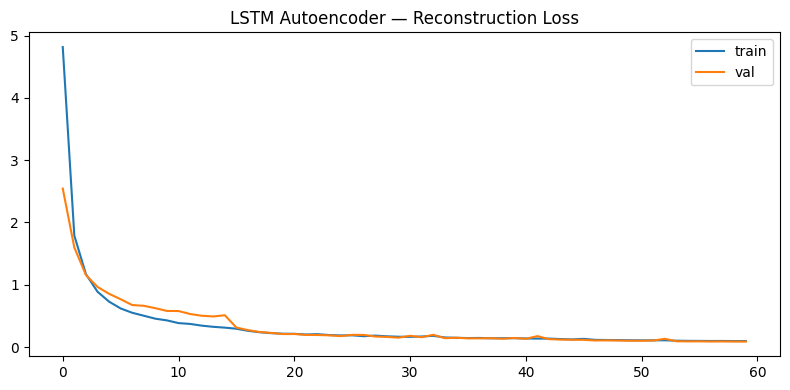

In [15]:
X_tr_ae, X_val_ae = train_test_split(X_train_ae, test_size=0.15, shuffle=False)

es_ae = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
lr_ae = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_ae = autoencoder.fit(
    X_tr_ae, X_tr_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=60, batch_size=128,
    callbacks=[es_ae, lr_ae], verbose=1,
)

plt.figure(figsize=(8,4))
plt.plot(history_ae.history["loss"], label="train")
plt.plot(history_ae.history["val_loss"], label="val")
plt.title("LSTM Autoencoder — Reconstruction Loss"); plt.legend(); plt.tight_layout(); plt.show()

Threshold (IQR) : 0.6236
Threshold (p95) : 1.0311


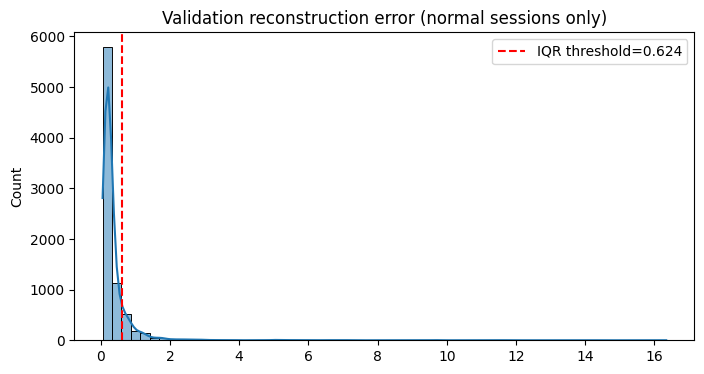

In [16]:
val_pred   = autoencoder.predict(X_val_ae, verbose=0)
# AFTER (isolates the worst moment in the window)
val_errors = np.max(np.mean(np.square(X_val_ae - val_pred), axis=2), axis=1)

Q1, Q3 = np.percentile(val_errors, [25, 75])
IQR     = Q3 - Q1
threshold = float(Q3 + 1.5 * IQR)   # standard Tukey fence
print(f"Threshold (IQR) : {threshold:.4f}")
print(f"Threshold (p95) : {np.percentile(val_errors, 95):.4f}")

with open(f"{artifacts_dir}/anomaly_threshold.json","w") as f:
    json.dump({"threshold": threshold, "Q1": float(Q1), "Q3": float(Q3), "IQR": float(IQR)}, f, indent=2)

plt.figure(figsize=(8,4))
sns.histplot(val_errors, bins=60, kde=True)
plt.axvline(threshold, color="red", linestyle="--", label=f"IQR threshold={threshold:.3f}")
plt.legend(); plt.title("Validation reconstruction error (normal sessions only)"); plt.show()

In [17]:
err_normal  = np.mean(np.square(X_test_normal  - autoencoder.predict(X_test_normal,  verbose=0)), axis=(1,2))
err_anomaly = np.max(np.mean(np.square(X_test_anomaly - autoencoder.predict(X_test_anomaly, verbose=0)), axis=2), axis=1)

all_errors = np.concatenate([err_normal, err_anomaly])
all_labels = np.array([0]*len(err_normal) + [1]*len(err_anomaly))

flags = (all_errors > threshold).astype(int)
tp = ((flags==1) & (all_labels==1)).sum()
fp = ((flags==1) & (all_labels==0)).sum()
fn = ((flags==0) & (all_labels==1)).sum()
precision = tp / max(1, tp+fp)
recall    = tp / max(1, tp+fn)
f1        = 2*precision*recall / max(1e-9, precision+recall)
auc       = roc_auc_score(all_labels, all_errors)

print(f"AUC-ROC   : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

AUC-ROC   : 0.9703
Precision : 0.5811
Recall    : 0.5969
F1        : 0.5889


In [18]:
autoencoder.export(f"{artifacts_dir}/anomaly_lstm_autoencoder")
# !python -m tf2onnx.convert --saved-model artifacts/anomaly_lstm_autoencoder \
#   --output artifacts/anomaly_lstm_autoencoder.onnx

#  ██████╗  █████╗ ██████╗ ████████╗     ██████╗
#  ██╔══██╗██╔══██╗██╔══██╗╚══██╔══╝    ██╔══██╗
#  ██████╔╝███████║██████╔╝   ██║       ██████╔╝
#  ██╔═══╝ ██╔══██║██╔══██╗   ██║       ██╔══██╗
#  ██║     ██║  ██║██║  ██║   ██║       ██████╔╝
#  ╚═╝     ╚═╝  ╚═╝╚═╝  ╚═╝   ╚═╝       ╚═════╝
#  GRU — Next-Action Prediction

Saved artifact at 'artifacts/anomaly_lstm_autoencoder'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name=None)
Captures:
  132749553508496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553512336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553515600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553515792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553515408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553510224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553515984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553511952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553513488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749553516368: TensorSpec(shape=(), dtype=tf.resource, name=None

In [19]:
num_actions = len(action_le.classes_)
classes_present = np.unique(y_train)
raw_weights = compute_class_weight("balanced", classes=classes_present, y=y_train)
raw_weights = np.clip(raw_weights, 0.1, 10.0)
class_weight_dict = {int(c): float(w) for c,w in zip(classes_present, raw_weights)}
for c in range(num_actions):
    class_weight_dict.setdefault(c, 1.0)
print(f"Class weights computed for {len(class_weight_dict)} classes.")

Class weights computed for 43 classes.


In [20]:
gru_in = layers.Input(shape=(SEQ_LEN, input_dim))
gx = layers.Masking(mask_value=0.0)(gru_in)
gx = layers.Bidirectional(layers.GRU(128, return_sequences=True))(gx)
gx = layers.Dropout(0.30)(gx)
gx = layers.Bidirectional(layers.GRU(64, return_sequences=False))(gx)
gx = layers.Dropout(0.30)(gx)
gx = layers.Dense(128, activation="relu")(gx)
gx = layers.Dropout(0.20)(gx)
gru_out = layers.Dense(num_actions, activation="softmax")(gx)

gru_model = models.Model(gru_in, gru_out, name="gru_next_action")
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
gru_model.summary()

Model: "gru_next_action"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 10, 22)    │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 10, 22)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 10)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 10, 256)   │    116,736 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 256)   │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │    123,648 │ dropout_2[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 43)        │      5,547 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 262,443 (1.00 MB)

 Trainable params: 262,443 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.0972 - loss: 2.9115 - val_accuracy: 0.1572 - val_loss: 3.1665 - learning_rate: 5.0000e-04
Epoch 2/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1448 - loss: 2.7408 - val_accuracy: 0.1590 - val_loss: 3.0806 - learning_rate: 5.0000e-04
Epoch 3/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1651 - loss: 2.6317 - val_accuracy: 0.2145 - val_loss: 2.8633 - learning_rate: 5.0000e-04
Epoch 4/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1992 - loss: 2.5297 - val_accuracy: 0.2769 - val_loss: 2.5951 - learning_rate: 5.0000e-04
Epoch 5/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2392 - loss: 2.4502 - val_accuracy: 0.3125 - val_loss: 2.5771 - learning_rate: 5.0000e-04
Epoch 6/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2783 - loss: 2.3793 - val_accuracy: 0.3578 - val_loss: 2.3471 - learning_rate: 5.0000e-04
Epoch 7/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc

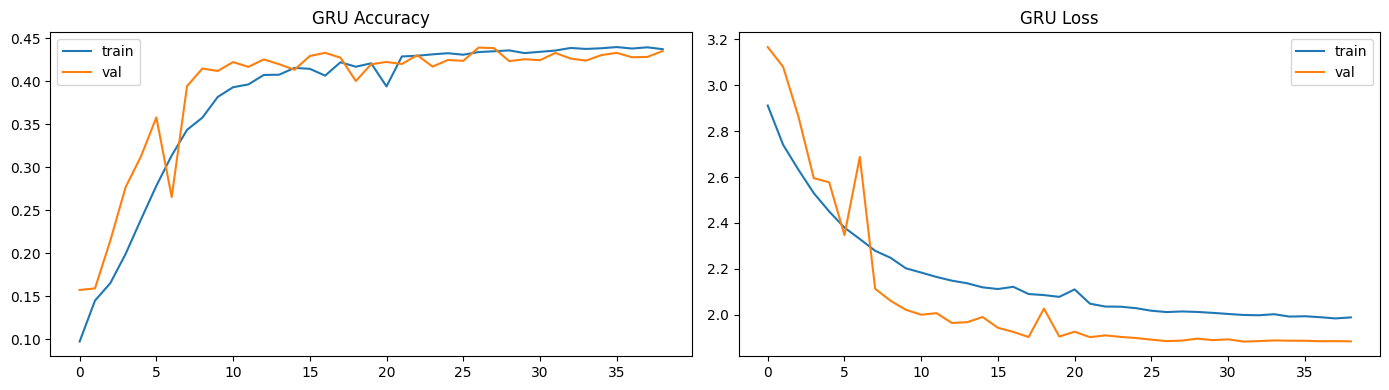

In [21]:
X_tr_gru, X_val_gru, y_tr_gru, y_val_gru = train_test_split(
    X_train, y_train, test_size=0.15, shuffle=False)

es_gru = callbacks.EarlyStopping(monitor="val_accuracy", patience=12,
                                  restore_best_weights=True, mode="max")
lr_gru = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                      patience=4, min_lr=1e-6, mode="max")

history_gru = gru_model.fit(
    X_tr_gru, y_tr_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=60, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[es_gru, lr_gru], verbose=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_gru.history["accuracy"], label="train")
ax1.plot(history_gru.history["val_accuracy"], label="val")
ax1.set_title("GRU Accuracy"); ax1.legend()
ax2.plot(history_gru.history["loss"], label="train")
ax2.plot(history_gru.history["val_loss"], label="val")
ax2.set_title("GRU Loss"); ax2.legend()
plt.tight_layout(); plt.show()

In [22]:
y_prob = gru_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Top-1 Accuracy : {acc:.4f}")
print(f"Macro-F1       : {f1:.4f}")

def top_k_accuracy(y_true, y_prob, k):
    topk = np.argsort(y_prob, axis=1)[:, -k:]
    return np.mean([1 if y_true[i] in topk[i] else 0 for i in range(len(y_true))])

for k in [1, 3, 5]:
    print(f"Top-{k} accuracy: {top_k_accuracy(y_test, y_prob, k):.4f}")

# Fixed: Pass explicit labels to ensure target_names match
all_labels = np.arange(len(action_le.classes_))
print(classification_report(y_test, y_pred,
                            labels=all_labels,
                            target_names=action_le.classes_,
                            zero_division=0))

Top-1 Accuracy : 0.4303
Macro-F1       : 0.1724
Top-1 accuracy: 0.4303
Top-3 accuracy: 0.6224
Top-5 accuracy: 0.7098
                                                                                                             precision    recall  f1-score   support

                                                                                       Activation de compte       0.00      0.00      0.00         3
                                                              Ajout de la carte tiers payant dans le wallet       0.01      0.09      0.02        22
                                                                                 Changement de Mot de passe       0.13      0.12      0.12       303
                                                           Changer l'organisme de rattachement sécu. Social       0.20      0.29      0.23       414
                                                                           Changer les coordonnées bancaire       0.20      0.08      0.1

In [23]:
gru_model.export(f"{artifacts_dir}/next_action_gru")
json.dump({int(i): cls for i,cls in enumerate(action_le.classes_)},
          open(f"{artifacts_dir}/next_action_label_map.json","w"), ensure_ascii=False, indent=2)
# !python -m tf2onnx.convert --saved-model artifacts/next_action_gru \
#   --output artifacts/next_action_gru.onnx --opset 13

#  ██████╗  █████╗ ██████╗ ████████╗      ██████╗
#  ██╔══██╗██╔══██╗██╔══██╗╚══██╔══╝     ██╔════╝
#  ██████╔╝███████║██████╔╝   ██║        ██║
#  ██╔═══╝ ██╔══██║██╔══██╗   ██║        ██║
#  ██║     ██║  ██║██║  ██║   ██║        ╚██████╗
#  ╚═╝     ╚═╝  ╚═╝╚═╝  ╚═╝   ╚═╝         ╚═════╝
#  XGBOOST — Daily trend forecasting

Saved artifact at 'artifacts/next_action_gru'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  132749365423440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367195408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367193680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367193104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367195600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367192720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367194640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367194064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367191568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749367189840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132749

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_daily = df.copy()
df_daily["date"] = df_daily["createdAt"].dt.date
daily_counts = (df_daily.groupby(["date","action"]).size()
                .reset_index(name="count"))
daily_counts["date"]      = pd.to_datetime(daily_counts["date"])
daily_counts["dayofweek"] = daily_counts["date"].dt.dayofweek
daily_counts["month_num"] = daily_counts["date"].dt.month
daily_counts["day"]       = daily_counts["date"].dt.day
daily_counts["is_weekend"]= (daily_counts["dayofweek"]>=5).astype(int)

# Encode action
actl = LabelEncoder()
daily_counts["action_id"] = actl.fit_transform(daily_counts["action"])
daily_counts = daily_counts.sort_values(["action_id","date"]).reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 30]:
    daily_counts[f"lag_{lag}"] = daily_counts.groupby("action_id")["count"].shift(lag)

daily_counts["rolling_mean_7"] = daily_counts.groupby("action_id")["count"].shift(1).rolling(7).mean()
daily_counts["rolling_std_7"]  = daily_counts.groupby("action_id")["count"].shift(1).rolling(7).std()
daily_counts["rolling_mean_30"]= daily_counts.groupby("action_id")["count"].shift(1).rolling(30).mean()
daily_counts = daily_counts.dropna().reset_index(drop=True)

feature_cols_trend = ["action_id","dayofweek","month_num","day","is_weekend",
                      "lag_1","lag_2","lag_3","lag_7","lag_14","lag_30",
                      "rolling_mean_7","rolling_std_7","rolling_mean_30"]
X_trend  = daily_counts[feature_cols_trend]
y_trend  = daily_counts["count"]
split_tr = int(len(daily_counts)*0.8)
X_tr_t, X_te_t = X_trend.iloc[:split_tr], X_trend.iloc[split_tr:]
y_tr_t, y_te_t = y_trend.iloc[:split_tr], y_trend.iloc[split_tr:]

In [25]:
trend_model = XGBRegressor(
    n_estimators=600, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric="mae",
)
trend_model.fit(X_tr_t, y_tr_t, eval_set=[(X_te_t, y_te_t)], verbose=50)

y_pred_t = trend_model.predict(X_te_t)
mae  = mean_absolute_error(y_te_t, y_pred_t)
rmse = math.sqrt(mean_squared_error(y_te_t, y_pred_t))
print(f"XGBoost  MAE  : {mae:.3f}")
print(f"XGBoost  RMSE : {rmse:.3f}")

joblib.dump(trend_model, f"{artifacts_dir}/trend_xgboost.pkl")
json.dump(feature_cols_trend, open(f"{artifacts_dir}/trend_feature_cols.json","w"))

#  ██████╗  █████╗ ██████╗ ████████╗    ██████╗
#  ██╔══██╗██╔══██╗██╔══██╗╚══██╔══╝    ██╔══██╗
#  ██████╔╝███████║██████╔╝   ██║       ██║  ██║
#  ██╔═══╝ ██╔══██║██╔══██╗   ██║       ██║  ██║
#  ██║     ██║  ██║██║  ██║   ██║       ██████╔╝
#  ╚═╝     ╚═╝  ╚═╝╚═╝  ╚═╝   ╚═╝       ╚═════╝
#  ANOMALY TYPE CLASSIFIER
#
#  Answers: "WHICH TYPE of anomaly is this?"
#  Runs AFTER the LSTM AE has flagged a sequence as anomalous.
#  Trained on labeled anomalous sequences (is_anomaly=1, anomaly_type=X).
#  Produces one of 6 labels → fed to LLM for explanation.

[0]	validation_0-mae:4.87182
[50]	validation_0-mae:2.34399
[100]	validation_0-mae:2.09458
[150]	validation_0-mae:2.06766
[189]	validation_0-mae:2.06631
XGBoost  MAE  : 2.066
XGBoost  RMSE : 2.827


In [26]:
ANOMALY_TYPES = ["rapid_fire","unusual_hour","geo_jump",
                 "repeated_fail","skip_login","impossible_seq"]

# We train on ALL sequences but use anomaly_type as target.
# Normal sequences get label "normal" → the classifier also handles "is this
# actually normal?" which adds robustness when AE has false positives.
#
# Target: 7 classes (normal + 6 anomaly types)
atype_le = LabelEncoder()
y_atype_all_arr = np.array(y_atype_all)
y_type_encoded  = atype_le.fit_transform(y_atype_all_arr)
num_anomaly_classes = len(atype_le.classes_)
print("Anomaly type classes:", atype_le.classes_)
print("Class distribution:"); print(pd.Series(y_atype_all_arr).value_counts())

# ── Build train/test for type classifier ──
y_type_train = y_type_encoded[:split]
y_type_test  = y_type_encoded[split:]

# Class weights for type classifier
classes_atype = np.unique(y_type_train)
raw_w_atype = compute_class_weight("balanced", classes=classes_atype, y=y_type_train)
raw_w_atype = np.clip(raw_w_atype, 0.1, 15.0)
cw_atype = {int(c): float(w) for c,w in zip(classes_atype, raw_w_atype)}
for c in range(num_anomaly_classes):
    cw_atype.setdefault(c, 1.0)

Anomaly type classes: ['UNKNOWN' 'geo_jump' 'impossible_seq' 'rapid_fire' 'repeated_fail'
 'skip_login' 'unusual_hour']
Class distribution:
UNKNOWN           66383
impossible_seq      830
repeated_fail       825
rapid_fire          519
unusual_hour        458
geo_jump            453
skip_login          447
Name: count, dtype: int64


In [27]:
tc_in = layers.Input(shape=(SEQ_LEN, input_dim))
tx = layers.Masking(mask_value=0.0)(tc_in)
tx = layers.Bidirectional(layers.GRU(128, return_sequences=True))(tx)
tx = layers.Dropout(0.25)(tx)
tx = layers.Bidirectional(layers.GRU(64, return_sequences=False))(tx)
tx = layers.Dropout(0.25)(tx)
tx = layers.Dense(128, activation="relu")(tx)
tx = layers.Dropout(0.20)(tx)
tc_out = layers.Dense(num_anomaly_classes, activation="softmax")(tx)

type_classifier = models.Model(tc_in, tc_out, name="anomaly_type_classifier")
type_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
type_classifier.summary()

Model: "anomaly_type_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 10, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 10, 22)    │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_2 (Masking) │ (None, 10, 22)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, 10)        │          0 │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 10, 256)   │    116,736 │ masking_2[0][0],  │
│ (Bidirectional)     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 10, 256)   │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 128)       │    123,648 │ dropout_5[0][0],  │
│ (Bidirectional)     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 7)         │        903 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 257,799 (1007.03 KB)

 Trainable params: 257,799 (1007.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3945 - loss: 1.1402 - val_accuracy: 0.5234 - val_loss: 1.2591 - learning_rate: 5.0000e-04
Epoch 2/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6579 - loss: 0.7036 - val_accuracy: 0.6428 - val_loss: 0.9726 - learning_rate: 5.0000e-04
Epoch 3/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7309 - loss: 0.5991 - val_accuracy: 0.9143 - val_loss: 0.5446 - learning_rate: 5.0000e-04
Epoch 4/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7656 - loss: 0.5417 - val_accuracy: 0.8979 - val_loss: 0.5177 - learning_rate: 5.0000e-04
Epoch 5/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7677 - loss: 0.5119 - val_accuracy: 0.9170 - val_loss: 0.4967 - learning_rate: 5.0000e-04
Epoch 6/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7653 - loss: 0.4744 - val_accuracy: 0.7958 - val_loss: 0.7105 - learning_rate: 5.0000e-04
Epoch 7/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - acc

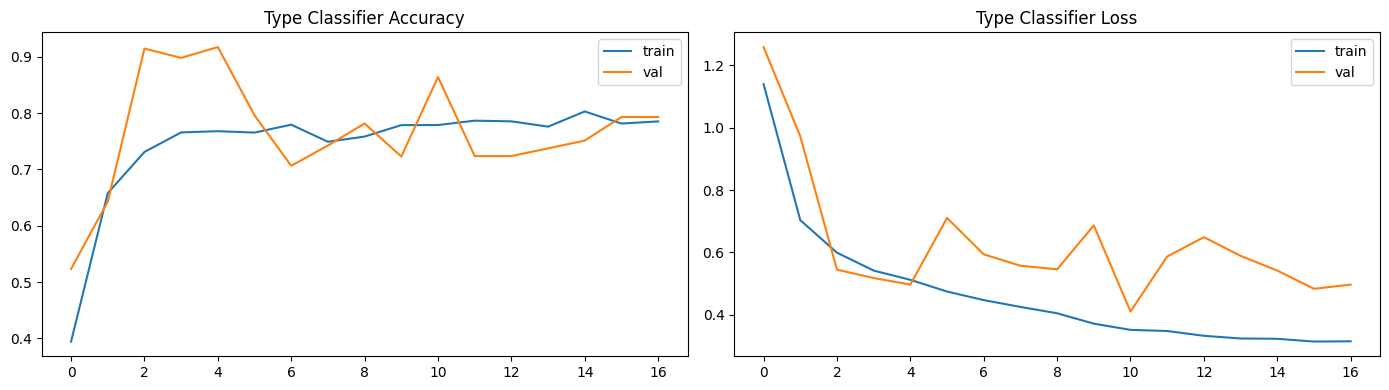

In [28]:
X_tr_tc, X_val_tc, y_tr_tc, y_val_tc = train_test_split(
    X_train, y_type_train, test_size=0.15, shuffle=False)

es_tc = callbacks.EarlyStopping(monitor="val_accuracy", patience=12,
                                 restore_best_weights=True, mode="max")
lr_tc = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                     patience=4, min_lr=1e-6, mode="max")

history_tc = type_classifier.fit(
    X_tr_tc, y_tr_tc,
    validation_data=(X_val_tc, y_val_tc),
    epochs=60, batch_size=128,
    class_weight=cw_atype,
    callbacks=[es_tc, lr_tc], verbose=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_tc.history["accuracy"], label="train")
ax1.plot(history_tc.history["val_accuracy"], label="val")
ax1.set_title("Type Classifier Accuracy"); ax1.legend()
ax2.plot(history_tc.history["loss"], label="train")
ax2.plot(history_tc.history["val_loss"], label="val")
ax2.set_title("Type Classifier Loss"); ax2.legend()
plt.tight_layout(); plt.show()

Overall accuracy: 0.8959450761639133

                precision    recall  f1-score   support

       UNKNOWN       0.99      0.91      0.95     13281
      geo_jump       0.22      0.31      0.26        85
impossible_seq       0.73      0.48      0.58       145
    rapid_fire       0.05      0.47      0.08       120
 repeated_fail       0.86      0.80      0.83       170
    skip_login       0.93      1.00      0.97        84
  unusual_hour       1.00      1.00      1.00        98

      accuracy                           0.90     13983
     macro avg       0.68      0.71      0.67     13983
  weighted avg       0.97      0.90      0.93     13983



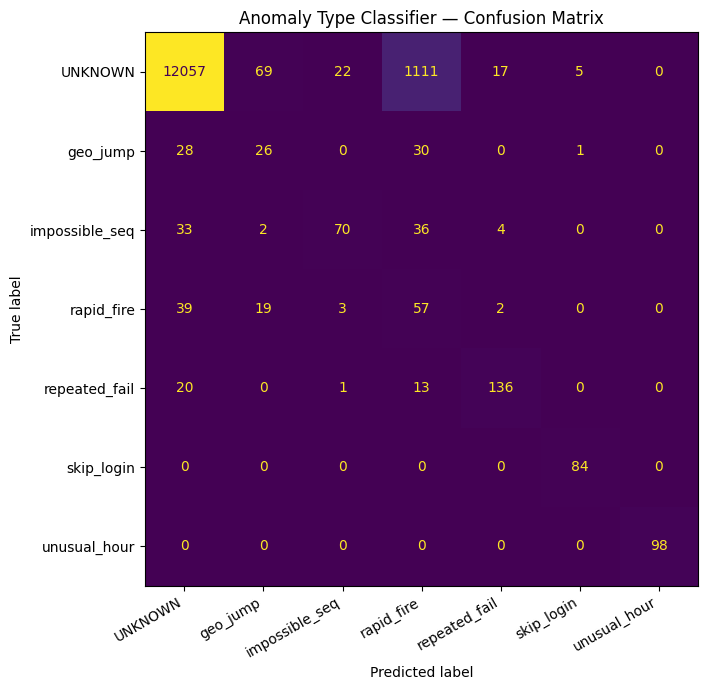


Among 702 truly anomalous sequences:
                precision    recall  f1-score   support

      geo_jump       0.55      0.31      0.39        85
impossible_seq       0.95      0.48      0.64       145
    rapid_fire       0.42      0.47      0.45       120
 repeated_fail       0.96      0.80      0.87       170
    skip_login       0.99      1.00      0.99        84
  unusual_hour       1.00      1.00      1.00        98

     micro avg       0.81      0.67      0.73       702
     macro avg       0.81      0.68      0.72       702
  weighted avg       0.82      0.67      0.73       702



In [29]:
y_tc_prob = type_classifier.predict(X_test, verbose=0)
y_tc_pred = np.argmax(y_tc_prob, axis=1)

print("Overall accuracy:", accuracy_score(y_type_test, y_tc_pred))
print()
print(classification_report(y_type_test, y_tc_pred,
      target_names=atype_le.classes_, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_type_test, y_tc_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=atype_le.classes_).plot(ax=ax, colorbar=False)
plt.title("Anomaly Type Classifier — Confusion Matrix")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

# ── Evaluate only on TRULY anomalous test sequences ──
# Note: In your dataset, 'UNKNOWN' is the label for normal sequences.
normal_label = "UNKNOWN" if "UNKNOWN" in atype_le.classes_ else atype_le.classes_[0]
anomaly_idx = np.where(y_type_test != atype_le.transform([normal_label])[0])[0]

if len(anomaly_idx) > 0:
    y_true_anom = y_type_test[anomaly_idx]
    y_pred_anom = y_tc_pred[anomaly_idx]

    # Filter out the normal class for the target names and labels
    anomaly_classes = [c for c in atype_le.classes_ if c != normal_label]
    anomaly_labels  = [i for i, c in enumerate(atype_le.classes_) if c != normal_label]

    print(f"\nAmong {len(anomaly_idx)} truly anomalous sequences:")
    print(classification_report(y_true_anom, y_pred_anom,
          target_names=anomaly_classes,
          labels=anomaly_labels,
          zero_division=0))

In [30]:
type_classifier.export(f"{artifacts_dir}/anomaly_type_classifier")
json.dump({int(i): cls for i,cls in enumerate(atype_le.classes_)},
          open(f"{artifacts_dir}/anomaly_type_label_map.json","w"), ensure_ascii=False, indent=2)
# !python -m tf2onnx.convert --saved-model artifacts/anomaly_type_classifier \
#   --output artifacts/anomaly_type_classifier.onnx --opset 13

Saved artifact at 'artifacts/anomaly_type_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132748919033296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919033488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919035024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919035216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919032144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919035600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919034256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919031568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919036944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132748919037136: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [31]:
# Upload anomaly_test_set.csv (generated by anomaly_test_generator.py)
# then run:

def evaluate_on_test_set(csv_path: str):
    """
    Load an externally generated test CSV (anomaly_test_generator.py output),
    run both the LSTM AE and the Type Classifier, print full evaluation.
    """
    df_t = pd.read_csv(csv_path)
    df_t["createdAt"] = pd.to_datetime(df_t["createdAt"], utc=True, errors="coerce")
    for c in ["action","type","subType","device","countryCode","city","status","userAgent","anomaly_type"]:
        if c in df_t.columns:
            df_t[c] = df_t[c].fillna("UNKNOWN").astype(str)
    if "is_anomaly" not in df_t.columns:
        df_t["is_anomaly"] = 0
    if "sessionLength" not in df_t.columns:
        df_t["sessionLength"] = df_t.groupby(["insuredId","sessionNumber"])["sequenceInSession"].transform("max")

    # Apply same encoders (handle unseen labels gracefully)
    def safe_transform(le, series):
        classes_set = set(le.classes_)
        return np.array([le.transform([v])[0] if v in classes_set else 0 for v in series])

    df_t["action_id"]  = safe_transform(action_le,  df_t["action"])
    df_t["device_id"]  = safe_transform(device_le,  df_t["device"])
    df_t["country_id"] = safe_transform(country_le, df_t["countryCode"])
    df_t["type_id"]    = safe_transform(type_le,    df_t["type"])
    df_t["subType_filled"] = df_t["subType"].fillna("NONE")
    df_t["subtype_id"] = safe_transform(subtype_le, df_t["subType_filled"])

    df_t["hour"]      = df_t["createdAt"].dt.hour
    df_t["dayofweek"] = df_t["createdAt"].dt.dayofweek
    df_t["month_num"] = df_t["createdAt"].dt.month
    df_t["hour_sin"]  = np.sin(2*np.pi*df_t["hour"]/24)
    df_t["hour_cos"]  = np.cos(2*np.pi*df_t["hour"]/24)
    df_t["dow_sin"]   = np.sin(2*np.pi*df_t["dayofweek"]/7)
    df_t["dow_cos"]   = np.cos(2*np.pi*df_t["dayofweek"]/7)
    df_t["is_ok"]     = (df_t["status"]=="OK").astype(int)
    df_t["is_ko"]     = (df_t["status"]=="KO").astype(int)

    SK = ["insuredId","sessionNumber"]
    df_t["prev_time"] = df_t.groupby(SK)["createdAt"].shift(1)
    df_t["delta_seconds"] = (df_t["createdAt"]-df_t["prev_time"]).dt.total_seconds().fillna(0)
    df_t["delta_scaled"]  = scaler_delta.transform(df_t[["delta_seconds".replace("_seconds","_seconds_clipped")
                                                           if "delta_seconds_clipped" in df_t.columns
                                                           else "delta_seconds"]].clip(0, 3600))
    df_t["seq_pos_norm"]     = df_t["sequenceInSession"] / df_t["sessionLength"]
    df_t["is_session_start"] = (df_t["sequenceInSession"]==1).astype(int)
    df_t["is_session_end"]   = (df_t["sequenceInSession"]==df_t["sessionLength"]).astype(int)
    df_t["prev_action_id"]   = (df_t.groupby(SK)["action_id"].shift(1).fillna(-1).astype(int)+1)
    df_t["ko_count_so_far"]  = (df_t.groupby(SK)["is_ko"].cumsum().shift(1).fillna(0).astype(int))
    df_t["session_len_norm"] = df_t["sessionLength"] / max_session_len
    df_t["ip_prev"]    = df_t.groupby(SK)["ip"].shift(1)
    df_t["ip_changed"] = ((df_t["ip"]!=df_t["ip_prev"]) & df_t["ip_prev"].notna()).astype(int)

    X_ext, y_anom_ext, y_type_ext, _, _ = build_sequences(df_t, SEQ_LEN)[:5]

    # AE evaluation
    preds_ae  = autoencoder.predict(X_ext, verbose=0)
    errors_ae = np.mean(np.square(X_ext - preds_ae), axis=(1,2))
    flags_ae  = (errors_ae > threshold).astype(int)

    print("═"*50)
    print("LSTM AE — Binary Detection")
    print(f"  Flagged {flags_ae.sum()}/{len(flags_ae)}  ({100*flags_ae.mean():.1f}%)")
    if y_anom_ext.sum() > 0:
        auc = roc_auc_score(y_anom_ext, errors_ae)
        print(f"  AUC-ROC : {auc:.4f}")

    # Type classifier evaluation
    preds_tc  = type_classifier.predict(X_ext, verbose=0)
    labels_tc = np.argmax(preds_tc, axis=1)
    safe_y_type = np.array([atype_le.transform([t])[0] if t in set(atype_le.classes_) else 0
                             for t in y_type_ext])
    print("\nAnomaly Type Classifier")
    print(classification_report(safe_y_type, labels_tc,
          target_names=atype_le.classes_, zero_division=0))

# Uncomment once you've uploaded anomaly_test_set.csv:
# evaluate_on_test_set("anomaly_test_set.csv")

In [32]:
# The outputs from the 4 models flow into your LLM like this:

LLM_PROMPT_TEMPLATE = """
You are a security analyst for a health insurance self-service portal.

SESSION SUMMARY:
  User: {insured_id}
  Device: {device}
  Country: {country}
  Session start: {session_start}
  Session length: {session_length} actions

ACTION SEQUENCE (last {seq_len} steps):
{action_sequence}

MODEL OUTPUTS:
  LSTM Autoencoder reconstruction error : {ae_score:.4f}  (threshold: {ae_threshold:.4f})
  Anomaly detected                       : {is_anomaly}
  Anomaly type (classifier)              : {anomaly_type}
  Confidence                             : {confidence:.1%}

  Next-action prediction (GRU top-3)    : {next_actions}

TASK:
1. Explain in plain French what anomaly type "{anomaly_type}" means in this context.
2. Describe the risk level (low / medium / high) with justification.
3. Suggest one concrete action the security team should take.
"""

print("LLM prompt template ready.")
print("\nAll models saved to artifacts/:")
import os
for f in sorted(os.listdir("artifacts")):
    print(f"  {f}")

LLM prompt template ready.

All models saved to artifacts/:
  action_vocab.json
  anomaly_lstm_autoencoder
  anomaly_threshold.json
  anomaly_type_classifier
  anomaly_type_label_map.json
  country_vocab.json
  device_vocab.json
  feature_config.json
  next_action_gru
  next_action_label_map.json
  scaler_delta.pkl
  subtype_vocab.json
  trend_feature_cols.json
  trend_xgboost.pkl
  type_vocab.json


In [33]:
!pip install -q tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 84.0 MB/s eta 0:00:00


In [34]:
import os, json, zipfile
from google.colab import files

artifacts_dir = "artifacts"

# ── ONNX conversion ────────────────────────────────────────────────────────────
onnx_models = [
    ("anomaly_lstm_autoencoder", "artifacts/anomaly_lstm_autoencoder.onnx"),
    ("next_action_gru",          "artifacts/next_action_gru.onnx"),
    ("anomaly_type_classifier",  "artifacts/anomaly_type_classifier.onnx"),
]
for saved_name, onnx_path in onnx_models:
    saved_path = f"{artifacts_dir}/{saved_name}"
    if os.path.exists(saved_path) and not os.path.exists(onnx_path):
        print(f"Converting {saved_name} ...")
        os.system(f"python -m tf2onnx.convert --saved-model {saved_path} --output {onnx_path} --opset 13")
        print("  OK" if os.path.exists(onnx_path) else "  FAILED")

# ── XGBoost export ────────────────────────────────────────────────────────────
if "trend_model" in globals():
    trend_model.save_model("artifacts/trend_xgboost.json")
    import joblib; joblib.dump(trend_model, "artifacts/trend_xgboost.pkl")

# ── Scaler export ─────────────────────────────────────────────────────────────
if "scaler_delta" in globals():
    import joblib
    with open("artifacts/scaler_delta.json", "w") as f:
        json.dump({"mean": list(scaler_delta.mean_), "scale": list(scaler_delta.scale_)}, f, indent=2)
    joblib.dump(scaler_delta, "artifacts/scaler_delta.pkl")

# ── trend_feature_cols.json ───────────────────────────────────────────────────
if "feature_cols_trend" in globals() and not os.path.exists("artifacts/trend_feature_cols.json"):
    with open("artifacts/trend_feature_cols.json", "w") as f:
        json.dump(feature_cols_trend, f)

# ── Complete bundle list ───────────────────────────────────────────────────────
bundle_files = [
    # ONNX models (for Java / Spring Boot)
    "artifacts/anomaly_lstm_autoencoder.onnx",
    "artifacts/next_action_gru.onnx",
    "artifacts/anomaly_type_classifier.onnx",
    # XGBoost (both formats — .json for XGBoost4J, .pkl as backup)
    "artifacts/trend_xgboost.json",
    "artifacts/trend_xgboost.pkl",
    "artifacts/trend_feature_cols.json",
    # Config & thresholds
    "artifacts/feature_config.json",
    "artifacts/anomaly_threshold.json",
    # Label maps
    "artifacts/next_action_label_map.json",
    "artifacts/anomaly_type_label_map.json",
    # Vocab maps (string → integer ID)
    "artifacts/action_vocab.json",
    "artifacts/device_vocab.json",
    "artifacts/country_vocab.json",
    "artifacts/type_vocab.json",
    "artifacts/subtype_vocab.json",
    # Scalers (both formats)
    "artifacts/scaler_delta.json",
    "artifacts/scaler_delta.pkl",
]

# ── Pre-flight check ──────────────────────────────────────────────────────────
print("\n── Artifact check ──────────────────────────────────────────────")
present, missing = [], []
for f in bundle_files:
    if os.path.exists(f):
        present.append(f)
        print(f"  ✅  {os.path.basename(f):52s} {os.path.getsize(f)/1024:8.1f} KB")
    else:
        missing.append(f)
        print(f"  ❌  {os.path.basename(f):52s} NOT FOUND")

if missing:
    print(f"\n⚠️  {len(missing)} file(s) missing — bundle will be incomplete!")
else:
    print(f"\n✅  All {len(bundle_files)} files present.")

# ── Zip and download ──────────────────────────────────────────────────────────
bundle_zip = "springboot_models_bundle.zip"
if os.path.exists(bundle_zip):
    os.remove(bundle_zip)

with zipfile.ZipFile(bundle_zip, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in present:
        z.write(f, arcname=os.path.basename(f))

print(f"\nCreated {bundle_zip}  ({len(present)} files, {os.path.getsize(bundle_zip)/1024:.0f} KB)")
files.download(bundle_zip)

Converting anomaly_lstm_autoencoder ...
  OK
Converting next_action_gru ...
  OK
Converting anomaly_type_classifier ...
  OK

── Artifact check ──────────────────────────────────────────────
  ✅  anomaly_lstm_autoencoder.onnx                           547.3 KB
  ✅  next_action_gru.onnx                                   1045.6 KB
  ✅  anomaly_type_classifier.onnx                           1028.4 KB
  ✅  trend_xgboost.json                                     1085.8 KB
  ✅  trend_xgboost.pkl                                       804.0 KB
  ✅  trend_feature_cols.json                                   0.2 KB
  ✅  feature_config.json                                       0.6 KB
  ✅  anomaly_threshold.json                                    0.1 KB
  ✅  next_action_label_map.json                                2.0 KB
  ✅  anomaly_type_label_map.json                               0.1 KB
  ✅  action_vocab.json                                         2.0 KB
  ✅  device_vocab.json                 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>